# 02. Pairwise EdgeMTSC -- четыре заполнения

Архитектура -- pairwise temporal IMP, SKB, LKB и два classification heads.
Для каждой пары latent channels остается свой kernel из пяти лагов.
Ширины `176 -> 44`, остальные блоки одинаковы во всех четырех запусках.
Модель обучаю с нуля для каждого заполнения.

1. `zero` -- физический ноль, до нормализации.
2. `mean` -- среднее наблюдаемых значений train-канала.
3. `median` -- медиана аналогично.
4. `linear` -- интерполяция только по наблюдениям этого окна и канала.

Заполняю все отсутствующие позиции: и редкую сетку, и интервалы отказа.
На validation/test применяю тот же метод с train-статистиками.
Ноль и mean не совпадают: нормализация общая, по наблюдаемым train-значениям.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd()
for folder in ["data", "figures", "results"]:
    (ROOT / folder).mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

from copy import deepcopy
import platform
import random
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 35
PATIENCE = 7
LR = 8e-4
WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
data = np.load(ROOT / "data/uci_har_missing.npz")
meta = json.loads((ROOT / "data/metadata.json").read_text())
X_train, y_train = data["X_train"], data["y_train"]
y_test, subjects_test = data["y_test"], data["subjects_test"]
fold_id, steps = data["fold_id"], data["steps"]
CLASS_NAMES = meta["classes"]

hardware = {
    "device": str(device), "platform": platform.platform(), "machine": platform.machine(),
    "processor": platform.processor(), "python": platform.python_version(),
    "torch": torch.__version__, "numpy": np.__version__, "threads": torch.get_num_threads(),
    "accelerator": torch.cuda.get_device_name(0) if device.type == "cuda" else str(device),
}
print(hardware)


{'device': 'mps', 'platform': 'macOS-15.7.7-arm64-arm-64bit-Mach-O', 'machine': 'arm64', 'processor': 'arm', 'python': '3.14.6', 'torch': '2.14.0', 'numpy': '2.5.3', 'threads': 10, 'accelerator': 'mps'}


### Общий протокол

Три fold по людям. Mean / median / std -- отдельно внутри каждого train fold.
Early stopping по validation macro F1, число финальных эпох -- медиана лучших эпох CV.
После этого обучаю с нуля на всем official train и оцениваю три фиксированных test-режима.

Окно целиком доступно для классификации -- двусторонняя интерполяция внутри него допустима.
Через границы окон ничего не интерполирую. Это offline-классификация, не causal forecasting.
Время inference -- прогретый batch, мс/объект, с синхронизацией устройства;
CPU-подготовка измеряется отдельно. CV std смешивает различия held-out групп людей и fold seeds; это не доверительный интервал и не отдельная оценка seed-устойчивости.


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def fit_stats(X):
    # Только наблюдаемые значения текущего train fold.
    return {
        "mean": np.nanmean(X, axis=(0, 2), keepdims=True),
        "median": np.nanmedian(X, axis=(0, 2), keepdims=True),
        "std": np.nanstd(X, axis=(0, 2), keepdims=True) + 1e-6,
    }


def prepare(X, stats, method):
    observed = np.isfinite(X)
    if method == "linear":
        filled = X.copy()
        grid = np.arange(X.shape[-1])
        for i in range(len(X)):
            for c in range(X.shape[1]):
                keep = observed[i, c]
                # На краях -- ближайшее наблюдение; пустой канал -- train mean.
                filled[i, c] = np.interp(grid, grid[keep], X[i, c, keep]) if keep.any() else stats["mean"][0, c, 0]
    elif method == "zero":
        filled = np.where(observed, X, 0.0)
    elif method in ["mean", "median"]:
        filled = np.where(observed, X, stats[method])
    else:
        # Нулевое хранение после нормализации -- значение не считается наблюдением.
        filled = np.where(observed, X, stats["mean"])
    scaled = ((filled - stats["mean"]) / stats["std"]).astype("float32")
    return scaled, observed


def make_loader(X, mask, y, shuffle=False, seed=SEED):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(mask), torch.from_numpy(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      generator=torch.Generator().manual_seed(seed), num_workers=0)


def sync():
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    truth, prediction = [], []
    loss_sum = 0.0
    for X, mask, y in loader:
        X, mask, y = X.to(device), mask.to(device), y.to(device)
        logits = model(X, mask)
        loss_sum += F.cross_entropy(logits, y).item() * len(y)
        truth.extend(y.cpu().numpy())
        prediction.extend(logits.argmax(1).cpu().numpy())
    return {
        "loss": loss_sum / len(truth),
        "accuracy": accuracy_score(truth, prediction),
        "balanced_accuracy": balanced_accuracy_score(truth, prediction),
        "macro_f1": f1_score(truth, prediction, labels=range(6), average="macro", zero_division=0),
        "y_true": np.asarray(truth), "y_pred": np.asarray(prediction),
    }


def fit(model, train_loader, val_loader=None, epochs=MAX_EPOCHS):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    # Один и тот же горизонт scheduler в CV и финальном обучении.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    history = []
    best_f1, best_epoch, best_state = -1.0, 0, None
    sync()
    started = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, total = 0.0, 0
        for X, mask, y in train_loader:
            X, mask, y = X.to(device), mask.to(device), y.to(device)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(X, mask), y, label_smoothing=LABEL_SMOOTHING)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_sum += loss.item() * len(y)
            total += len(y)
        scheduler.step()
        row = {"epoch": epoch, "train_loss": loss_sum / total}
        if val_loader is not None:
            val = evaluate(model, val_loader)
            row.update(val_loss=val["loss"], val_f1=val["macro_f1"])
            if val["macro_f1"] > best_f1:
                best_f1, best_epoch = val["macro_f1"], epoch
                best_state = deepcopy(model.state_dict())
        history.append(row)
        print(f"epoch {epoch:02d} -- loss {row['train_loss']:.4f}" +
              (f" -- val F1 {row['val_f1']:.4f}" if val_loader is not None else ""))
        if val_loader is not None and epoch - best_epoch >= PATIENCE:
            break
    sync()
    elapsed = time.perf_counter() - started
    if val_loader is not None:
        model.load_state_dict(best_state)
    return history, best_epoch, elapsed


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def latency_ms(model, X, mask, repeats=30):
    model.eval()
    batch = torch.from_numpy(X[:BATCH_SIZE]).to(device)
    batch_mask = torch.from_numpy(mask[:BATCH_SIZE]).to(device)
    for _ in range(10):
        model(batch, batch_mask)
    sync()
    started = time.perf_counter()
    for _ in range(repeats):
        model(batch, batch_mask)
    sync()
    return (time.perf_counter() - started) * 1000 / repeats / len(batch)


### Модель

Исходные pairwise-блоки сохраняю, включая BatchNorm по временной оси в IMP.
Маску CNN не использует -- она получает только заполненный плотный ряд.


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1, padding=0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class PairwiseTemporalIMP(nn.Module):
    # Для каждой пары latent channels учу свой temporal kernel --
    # так получаю отдельную banded Toeplitz matrix для связи source -> target.
    def __init__(self, channels, seq_len=128, kernel_size=5):
        super().__init__()
        self.mix = nn.Conv1d(
            channels, channels, kernel_size,
            padding=kernel_size // 2, bias=False,
        )
        self.bn = nn.BatchNorm1d(seq_len)

    def forward(self, x):
        message = self.mix(x)
        x = (x + message).transpose(1, 2)
        return F.relu(self.bn(x).transpose(1, 2))


class SKB(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv3 = nn.Conv1d(channels, channels, 3, padding=1, groups=channels, bias=False)
        self.conv1 = nn.Conv1d(channels, channels, 1, groups=channels, bias=False)
        self.bn3 = nn.BatchNorm1d(channels)
        self.bn1 = nn.BatchNorm1d(channels)
        self.bn_id = nn.BatchNorm1d(channels)

    def forward(self, x):
        return F.relu(self.bn3(self.conv3(x)) + self.bn1(self.conv1(x)) + self.bn_id(x))


class LKB(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.origin = nn.Sequential(
            nn.Conv1d(channels, channels, 47, padding=23, groups=channels, bias=False),
            nn.BatchNorm1d(channels),
        )
        self.branches = nn.ModuleList()
        for kernel, dilation in zip([5, 23, 3, 3, 3], [1, 2, 21, 19, 17]):
            padding = (dilation * (kernel - 1) + 1) // 2
            self.branches.append(nn.Sequential(
                nn.Conv1d(
                    channels, channels, kernel,
                    padding=padding, dilation=dilation,
                    groups=channels, bias=False,
                ),
                nn.BatchNorm1d(channels),
            ))

    def forward(self, x):
        out = self.origin(x)
        for branch in self.branches:
            out = out + branch(x)
        return out + x


class PairwiseEdgeMTSC(nn.Module):
    def __init__(self, hidden=(176, 44), temporal_kernel=5, dropout=0.2):
        super().__init__()
        h1, h2 = hidden

        self.up1 = ConvBlock(9, h1)
        self.imp1 = PairwiseTemporalIMP(h1, kernel_size=temporal_kernel)
        self.skb = SKB(h1)

        self.up2 = ConvBlock(h1, h2)
        self.imp2 = PairwiseTemporalIMP(h2, kernel_size=temporal_kernel)
        self.lkb = LKB(h2)

        self.linear_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(h2, 6)
        )
        self.conv_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(h2, 6, 1),
            nn.BatchNorm1d(6),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Flatten(),
        )

    def forward(self, x, mask=None):
        x = self.skb(self.imp1(self.up1(x)))
        x = self.imp2(self.up2(x))
        x = F.relu(self.lkb(x) + x)
        return (self.linear_head(x) + self.conv_head(x)) / 2


In [4]:
set_seed(SEED)
print("params:", count_parameters(PairwiseEdgeMTSC()))


params: 181376


### Обучение и сохранение

Сохраняю checkpoint, train-статистики, конфигурацию устройства и обучения,
истории, предсказания и метрики. Все четыре конфигурации заданы до просмотра test.


In [5]:
def run_experiment(name, factory, method):
    cv_rows, histories = [], []
    for fold in range(3):
        seed = SEED + fold + 1
        set_seed(seed)
        fit_idx, val_idx = fold_id != fold, fold_id == fold
        stats = fit_stats(X_train[fit_idx])
        X_fit, M_fit = prepare(X_train[fit_idx], stats, method)
        X_val, M_val = prepare(X_train[val_idx], stats, method)
        train_loader = make_loader(X_fit, M_fit, y_train[fit_idx], True, seed)
        val_loader = make_loader(X_val, M_val, y_train[val_idx])
        model = factory().to(device)
        print(name, "-- fold", fold + 1)
        history, best_epoch, elapsed = fit(model, train_loader, val_loader)
        val = evaluate(model, val_loader)
        cv_rows.append({"fold": fold + 1, "best_epoch": best_epoch, "time_s": elapsed,
                        **{k: val[k] for k in ["accuracy", "balanced_accuracy", "macro_f1"]}})
        histories.extend([dict(fold=fold + 1, **row) for row in history])
    cv = pd.DataFrame(cv_rows)
    cv.to_csv(ROOT / f"results/{name}_cv.csv", index=False)
    pd.DataFrame(histories).to_csv(ROOT / f"results/{name}_history.csv", index=False)

    # Число эпох выбираю по CV -- test до этого не участвует ни в одном решении.
    epochs = max(1, int(np.median(cv["best_epoch"])))
    stats = fit_stats(X_train)
    set_seed(SEED)
    model = factory().to(device)
    X_fit, M_fit = prepare(X_train, stats, method)
    final_history, _, elapsed = fit(model, make_loader(X_fit, M_fit, y_train, True), epochs=epochs)
    pd.DataFrame(final_history).to_csv(ROOT / f"results/{name}_final_history.csv", index=False)
    np.savez(ROOT / f"results/{name}_stats.npz", **stats)
    torch.save({k: v.detach().cpu() for k, v in model.state_dict().items()}, ROOT / f"results/{name}.pt")
    config = dict(model=name, imputation=method, seed=SEED, batch_size=BATCH_SIZE,
                  max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=LR, weight_decay=WEIGHT_DECAY,
                  label_smoothing=LABEL_SMOOTHING, final_epochs=epochs, data=meta,
                  hardware=hardware, architecture=str(model))
    if hasattr(model, "adapter"):
        config["adapter"] = {"patch_sizes": model.adapter.patch_sizes,
                             "patch_drop": model.adapter.patch_drop,
                             "use_mask": model.adapter.use_mask,
                             "cross_channel": model.adapter.cross_channel}
    (ROOT / f"results/{name}_config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2))

    rows = []
    for missing in [0, 25, 50]:
        started = time.perf_counter()
        X_eval, M_eval = prepare(data[f"X_test_{missing}"], stats, method)
        prep_ms = (time.perf_counter() - started) * 1000 / len(X_eval)
        test = evaluate(model, make_loader(X_eval, M_eval, y_test))
        rows.append({
            "model": name, "gap_pct": missing, "params": count_parameters(model),
            "cv_f1_mean": cv["macro_f1"].mean(), "cv_f1_std": cv["macro_f1"].std(),
            "final_epochs": epochs, "train_time_s": elapsed, "cv_time_s": cv["time_s"].sum(),
            "latency_ms": latency_ms(model, X_eval, M_eval), "prepare_ms": prep_ms,
            **{k: test[k] for k in ["accuracy", "balanced_accuracy", "macro_f1"]},
        })
        pd.DataFrame({"subject": subjects_test, "true": y_test, "pred": test["y_pred"]}).to_csv(
            ROOT / f"results/{name}_test_{missing}_predictions.csv", index=False)
        if missing == 25:
            report = pd.DataFrame(classification_report(
                y_test, test["y_pred"], labels=range(6), target_names=CLASS_NAMES,
                output_dict=True, zero_division=0)).T
            report.to_csv(ROOT / f"results/{name}_class_report.csv")
            plt.figure(figsize=(8, 6))
            sns.heatmap(confusion_matrix(y_test, test["y_pred"], labels=range(6)), annot=True,
                        fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
            plt.xlabel("pred"); plt.ylabel("true"); plt.title(name + " -- test 25%")
            plt.tight_layout()
            plt.savefig(ROOT / f"figures/{name}_confusion.png", dpi=150)
            plt.show()
    result = pd.DataFrame(rows)
    result.to_csv(ROOT / f"results/{name}_results.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for fold in range(1, 4):
        h = pd.DataFrame(histories).query("fold == @fold")
        axes[0].plot(h.epoch, h.train_loss, label=f"fold {fold}")
        axes[1].plot(h.epoch, h.val_f1, label=f"fold {fold}")
    axes[0].set_title("Train loss"); axes[1].set_title("Validation macro F1")
    for ax in axes:
        ax.set_xlabel("epoch"); ax.legend()
    fig.suptitle(name)
    plt.tight_layout()
    plt.savefig(ROOT / f"figures/{name}_learning.png", dpi=150)
    plt.show()
    return result


02_zero -- fold 1
epoch 01 -- loss 0.8878 -- val F1 0.9017
epoch 02 -- loss 0.4799 -- val F1 0.9388
epoch 03 -- loss 0.4022 -- val F1 0.9452
epoch 04 -- loss 0.3820 -- val F1 0.9537
epoch 05 -- loss 0.3727 -- val F1 0.9540
epoch 06 -- loss 0.3615 -- val F1 0.9677
epoch 07 -- loss 0.3517 -- val F1 0.9640
epoch 08 -- loss 0.3542 -- val F1 0.9251
epoch 09 -- loss 0.3525 -- val F1 0.9453
epoch 10 -- loss 0.3462 -- val F1 0.9542
epoch 11 -- loss 0.3498 -- val F1 0.9360
epoch 12 -- loss 0.3418 -- val F1 0.9193
epoch 13 -- loss 0.3356 -- val F1 0.9448
02_zero -- fold 2
epoch 01 -- loss 0.8229 -- val F1 0.8448
epoch 02 -- loss 0.3897 -- val F1 0.8754
epoch 03 -- loss 0.3324 -- val F1 0.8815
epoch 04 -- loss 0.3168 -- val F1 0.8491
epoch 05 -- loss 0.3050 -- val F1 0.8441
epoch 06 -- loss 0.3055 -- val F1 0.8625
epoch 07 -- loss 0.3024 -- val F1 0.8814
epoch 08 -- loss 0.2959 -- val F1 0.8760
epoch 09 -- loss 0.2938 -- val F1 0.8713
epoch 10 -- loss 0.2967 -- val F1 0.8393
02_zero -- fold 3
epo

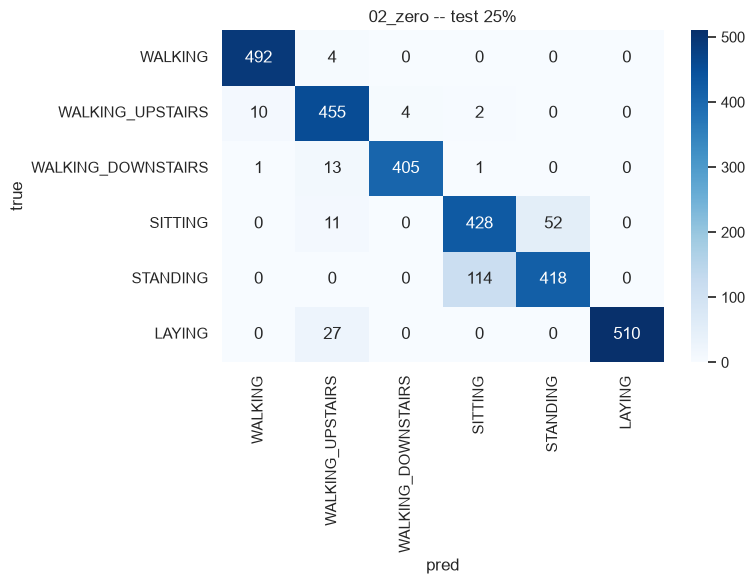

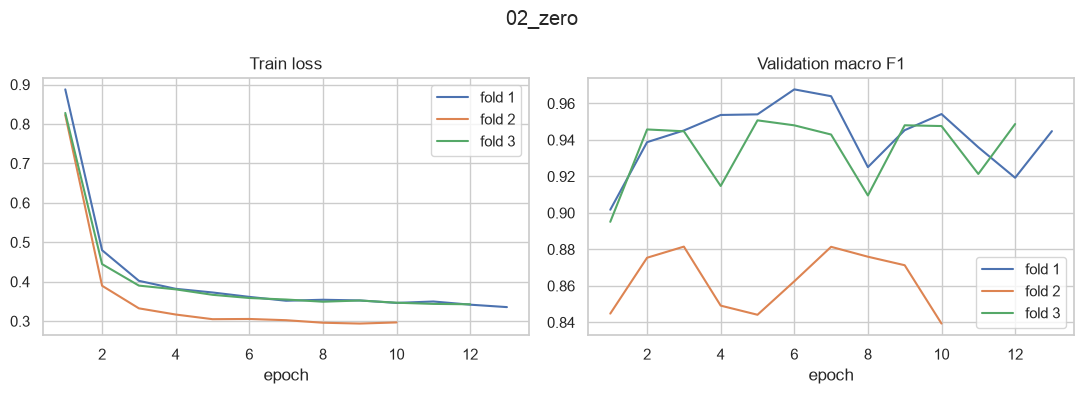

02_mean -- fold 1
epoch 01 -- loss 0.9041 -- val F1 0.9115
epoch 02 -- loss 0.4728 -- val F1 0.9349
epoch 03 -- loss 0.3933 -- val F1 0.9495
epoch 04 -- loss 0.3736 -- val F1 0.9575
epoch 05 -- loss 0.3603 -- val F1 0.9539
epoch 06 -- loss 0.3508 -- val F1 0.9604
epoch 07 -- loss 0.3433 -- val F1 0.9622
epoch 08 -- loss 0.3380 -- val F1 0.9513
epoch 09 -- loss 0.3341 -- val F1 0.8962
epoch 10 -- loss 0.3250 -- val F1 0.9520
epoch 11 -- loss 0.3277 -- val F1 0.9415
epoch 12 -- loss 0.3222 -- val F1 0.8836
epoch 13 -- loss 0.3138 -- val F1 0.9627
epoch 14 -- loss 0.3072 -- val F1 0.9276
epoch 15 -- loss 0.3066 -- val F1 0.9486
epoch 16 -- loss 0.2984 -- val F1 0.9632
epoch 17 -- loss 0.2974 -- val F1 0.9516
epoch 18 -- loss 0.2944 -- val F1 0.9646
epoch 19 -- loss 0.2886 -- val F1 0.9441
epoch 20 -- loss 0.2860 -- val F1 0.9517
epoch 21 -- loss 0.2844 -- val F1 0.9431
epoch 22 -- loss 0.2829 -- val F1 0.9564
epoch 23 -- loss 0.2748 -- val F1 0.9498
epoch 24 -- loss 0.2782 -- val F1 0.950

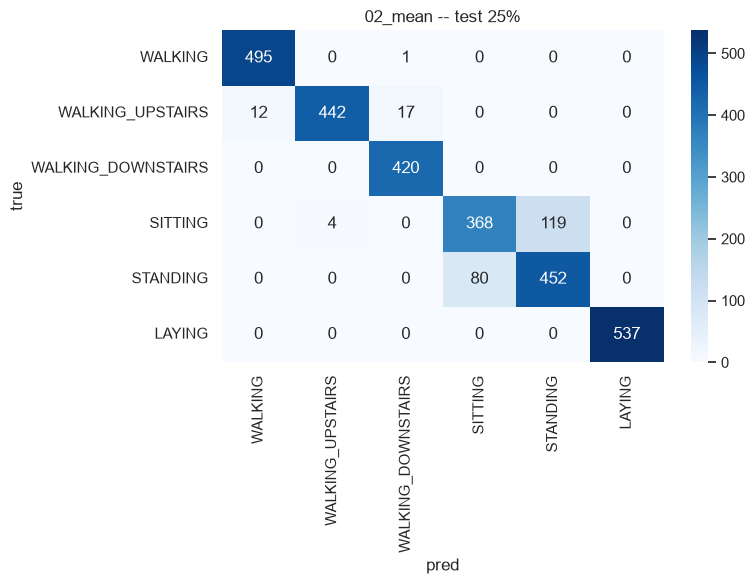

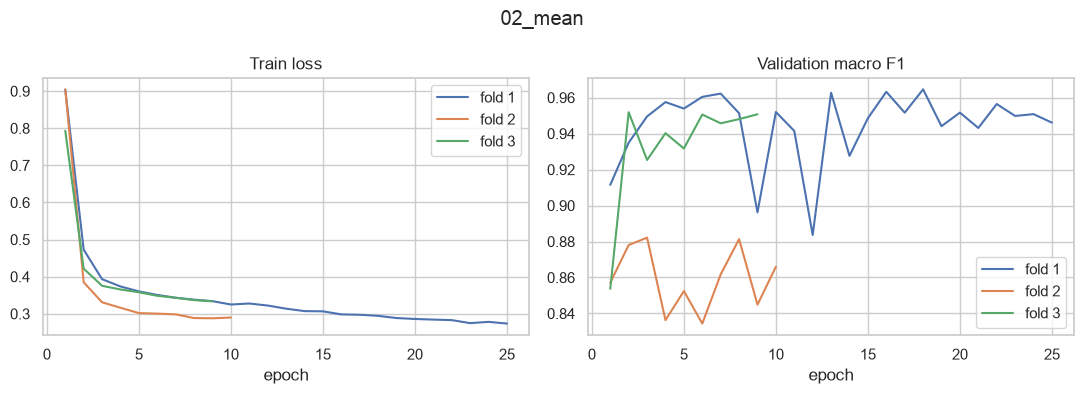

02_median -- fold 1
epoch 01 -- loss 0.9029 -- val F1 0.8899
epoch 02 -- loss 0.4674 -- val F1 0.9390
epoch 03 -- loss 0.3864 -- val F1 0.9438
epoch 04 -- loss 0.3724 -- val F1 0.9573
epoch 05 -- loss 0.3575 -- val F1 0.9534
epoch 06 -- loss 0.3473 -- val F1 0.9689
epoch 07 -- loss 0.3349 -- val F1 0.9436
epoch 08 -- loss 0.3319 -- val F1 0.9477
epoch 09 -- loss 0.3288 -- val F1 0.9405
epoch 10 -- loss 0.3203 -- val F1 0.9456
epoch 11 -- loss 0.3189 -- val F1 0.9499
epoch 12 -- loss 0.3117 -- val F1 0.9128
epoch 13 -- loss 0.3041 -- val F1 0.9427
02_median -- fold 2
epoch 01 -- loss 0.9193 -- val F1 0.8454
epoch 02 -- loss 0.3770 -- val F1 0.8794
epoch 03 -- loss 0.3281 -- val F1 0.8854
epoch 04 -- loss 0.3117 -- val F1 0.8720
epoch 05 -- loss 0.2970 -- val F1 0.8515
epoch 06 -- loss 0.2936 -- val F1 0.8611
epoch 07 -- loss 0.2870 -- val F1 0.8641
epoch 08 -- loss 0.2802 -- val F1 0.8716
epoch 09 -- loss 0.2771 -- val F1 0.8374
epoch 10 -- loss 0.2775 -- val F1 0.8492
02_median -- fold

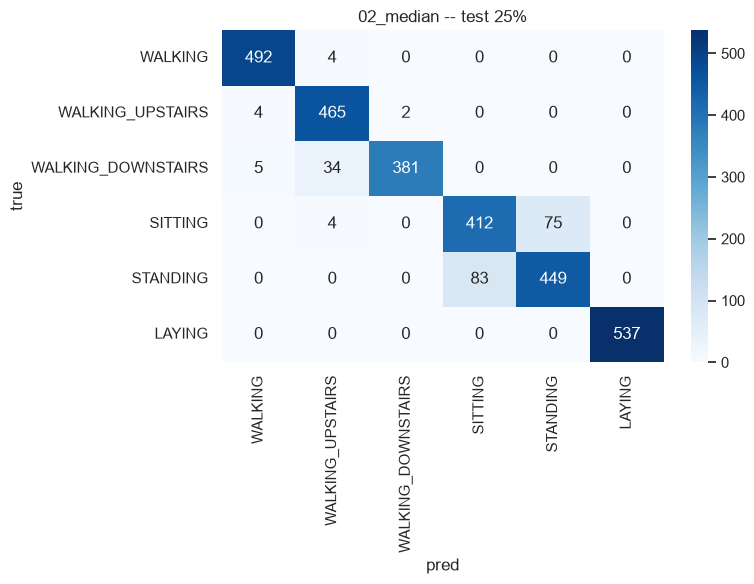

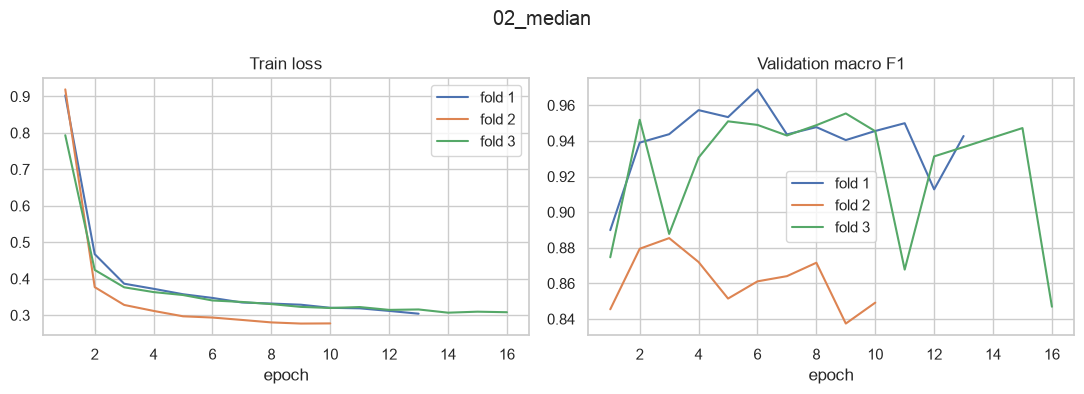

02_linear -- fold 1
epoch 01 -- loss 0.8655 -- val F1 0.8442
epoch 02 -- loss 0.4369 -- val F1 0.9503
epoch 03 -- loss 0.3814 -- val F1 0.9576
epoch 04 -- loss 0.3641 -- val F1 0.9579
epoch 05 -- loss 0.3529 -- val F1 0.9598
epoch 06 -- loss 0.3432 -- val F1 0.9606
epoch 07 -- loss 0.3357 -- val F1 0.9568
epoch 08 -- loss 0.3381 -- val F1 0.9514
epoch 09 -- loss 0.3270 -- val F1 0.9405
epoch 10 -- loss 0.3242 -- val F1 0.9528
epoch 11 -- loss 0.3331 -- val F1 0.9561
epoch 12 -- loss 0.3210 -- val F1 0.9434
epoch 13 -- loss 0.3181 -- val F1 0.9556
02_linear -- fold 2
epoch 01 -- loss 0.8321 -- val F1 0.7924
epoch 02 -- loss 0.3586 -- val F1 0.8642
epoch 03 -- loss 0.3218 -- val F1 0.8508
epoch 04 -- loss 0.3120 -- val F1 0.8443
epoch 05 -- loss 0.3014 -- val F1 0.8389
epoch 06 -- loss 0.2936 -- val F1 0.8664
epoch 07 -- loss 0.2894 -- val F1 0.8560
epoch 08 -- loss 0.2883 -- val F1 0.8643
epoch 09 -- loss 0.2856 -- val F1 0.8475
epoch 10 -- loss 0.2814 -- val F1 0.8520
epoch 11 -- loss 

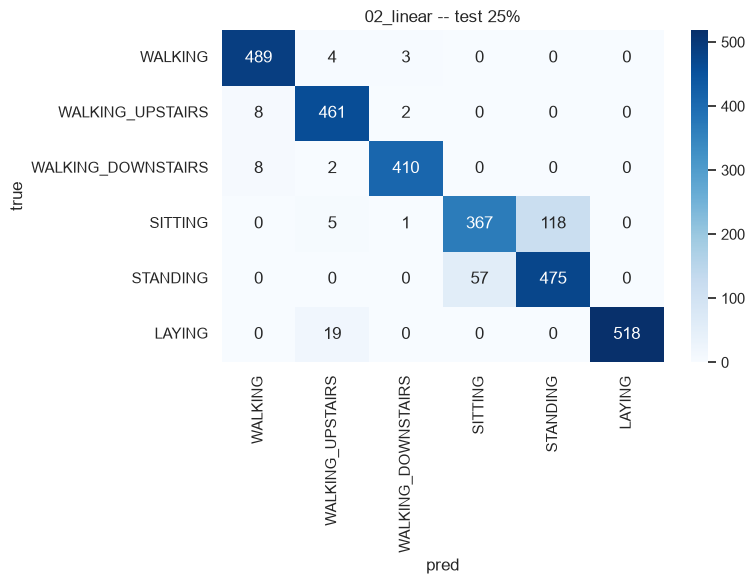

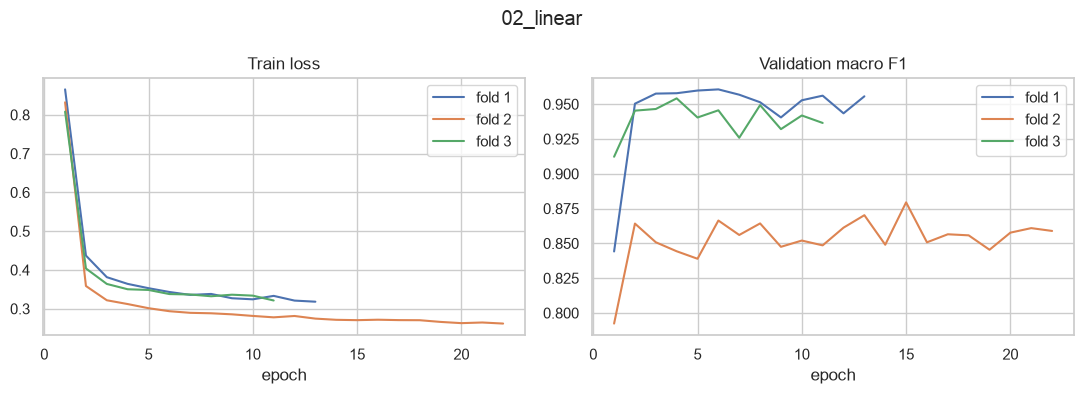

,gap_pct,params,cv_f1_mean,cv_f1_std,final_epochs,train_time_s,cv_time_s,latency_ms,prepare_ms,accuracy,balanced_accuracy,macro_f1
model,,,,,,,,,,,,
02_zero,25,181376,0.9333,0.0457,5,7.1499,38.3922,0.0312,0.0071,0.9189,0.9216,0.9207
02_mean,25,181376,0.9329,0.0444,3,4.0352,44.4116,0.0310,0.0070,0.9209,0.9226,0.9222
02_median,25,181376,0.9366,0.0448,6,8.0670,39.3769,0.0311,0.0065,0.9284,0.9282,0.9288
02_linear,25,181376,0.9314,0.0451,6,8.0730,46.2863,0.0312,0.0372,0.9230,0.9243,0.9242


In [6]:
baseline_results = []
for method in ["zero", "mean", "median", "linear"]:
    baseline_results.append(run_experiment("02_" + method, PairwiseEdgeMTSC, method))
baseline_results = pd.concat(baseline_results, ignore_index=True)
baseline_results.to_csv(ROOT / "results/02_comparison.csv", index=False)
main = baseline_results.query("gap_pct == 25").set_index("model")
display(main.round(4))


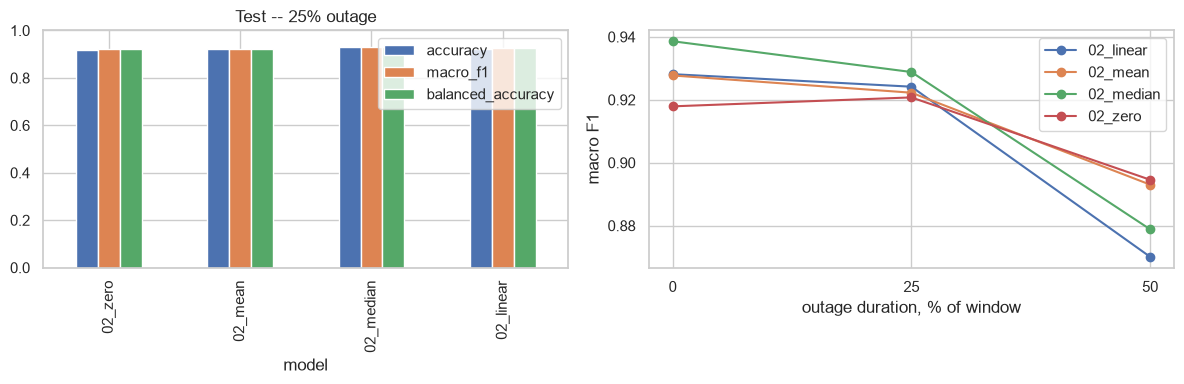

Среди заполнений по CV выбран 02_median: macro F1 = 0.9366. Его test macro F1 при 25% отказа = 0.9288. На этом корпусе и при умеренном outage простая медианная импутация остается сильным baseline; test не участвовал в выборе метода.


168

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
main[["accuracy", "macro_f1", "balanced_accuracy"]].plot.bar(ax=axes[0], ylim=(0, 1))
for name, group in baseline_results.groupby("model"):
    axes[1].plot(group.gap_pct, group.macro_f1, marker="o", label=name)
axes[0].set_title("Test -- 25% outage")
axes[1].set(xlabel="outage duration, % of window", ylabel="macro F1", xticks=[0, 25, 50])
axes[1].legend()
plt.tight_layout()
plt.savefig(ROOT / "figures/02_comparison.png", dpi=150)
plt.show()

best = main.cv_f1_mean.idxmax()
summary = (f"Среди заполнений по CV выбран {best}: macro F1 = {main.loc[best, 'cv_f1_mean']:.4f}. "
           f"Его test macro F1 при 25% отказа = {main.loc[best, 'macro_f1']:.4f}. "
           "Выбор сделан по CV, test только описывает перенос на новых людей.")
print(summary)
(ROOT / "results/02_conclusion.txt").write_text(summary)


### Как интерпретирую

По CV среди четырех способов заполнения выбран `median`: CV macro F1 = 0.9366.
На основном test с 25% отказа он дает macro F1 = 0.9288 и остается сильным baseline.

Для UCI HAR это правдоподобный результат: короткие окна инерциальных сигналов обладают локальной
временной гладкостью, а несколько каналов описывают одно и то же движение с разных компонент.
Кроме того, здесь решается классификация целого окна, поэтому модели не требуется точно
восстанавливать каждый скрытый отсчет. В таких условиях устойчивого типичного значения канала
может быть достаточно, чтобы не разрушить полезную для класса структуру.

Это вывод именно для данного корпуса и режима повреждения. Он не означает, что медианная
импутация в общем случае лучше специализированной обработки пропусков: при более длинных
периодах отсутствия наблюдений полезной временной информации остается существенно меньше.